In [116]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from html5lib.treeadapters.sax import prefix
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from xgboost.core import XGBoostError

path = r"C:\Users\mgori\OneDrive\Desktop\BIOSTAT__TRAINEE\INFLAM\Multisystem_Inflammatory_Syndrome_in_Children_(MIS-C)_National_Surveillance_-_(February_2020_-_December_2022)_20260407.csv"
data = pd.read_csv(path)
data.head(5)
# data.shape   ## (9332, 56)

,Case ID,Census Region,Sex,Age Group,Ethnicity,White Race,Black Race,Other Race,Unknown Race,MIS-C Onset (Month/Year),...,Treated with Immune modulators,Treated with Antiplatelets,Treated with Anticoagulation,Dialysis,First IVIG,Second IVIG,Vaccine Eligiblity,Vaccination Status,Number of Doses Received,Vaccine Type
0,1,South,Male,12-15 years,Unknown,False,True,False,False,01/2021,...,False,True,False,False,True,False,Vaccine ineligible,NaN,NaN,NaN
1,3619,Northeast,Male,1-4 years,Unknown,False,False,False,True,11/2021,...,False,True,True,False,True,False,Vaccine ineligible,NaN,NaN,NaN
2,2,West,Male,5-11 years,Hispanic or Latino,False,False,True,False,10/2020,...,False,True,True,False,True,False,Vaccine ineligible,NaN,NaN,NaN
3,3,South,Male,1-4 years,Not Hispanic or Latino,True,False,False,False,09/2020,...,True,True,True,False,False,False,Vaccine ineligible,NaN,NaN,NaN
4,4,South,Female,12-15 years,Unknown,False,False,False,True,10/2021,...,False,True,True,False,True,False,Vaccine eligible,Unknown,NaN,NaN


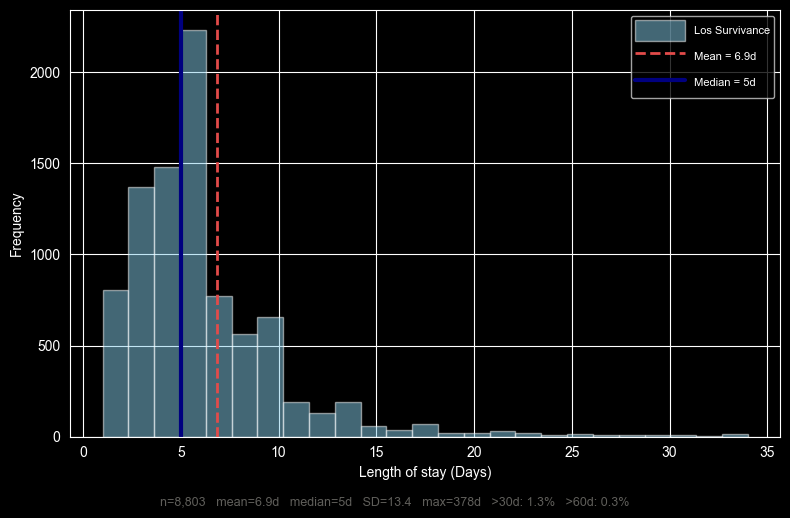

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

los = data['Hospital Length of Stay (Days)']
los = los[los >= 1]

mean_los = los.mean()
median_los = los.median()
var_los = los.var()
p99_los = np.percentile(los, 99)
los_trun = los[los <= p99_los]
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(los_trun, bins=25, color='skyblue', alpha=0.5, label='Los Survivance')
ax.axvline(mean_los, color='#E24B4A', linewidth=2,
           linestyle='--', label=f'Mean = {mean_los:.1f}d')
ax.axvline(median_los, color='navy', linewidth=3,
           linestyle='-', label=f'Median = {median_los:.0f}d')
ax.set_xlabel('Length of stay (Days)')
ax.set_ylabel('Frequency')

stats_text = (f'n={len(los):,}   mean={mean_los:.1f}d   '
              f'median={median_los:.0f}d   SD={los.std():.1f}   '
              f'max={los.max():.0f}d   '
              f'>30d: {(los > 30).mean() * 100:.1f}%   '
              f'>60d: {(los > 60).mean() * 100:.1f}%')
fig.text(0.5, -0.02, stats_text, ha='center',
         fontsize=9, color='#5F5E5A')
plt.legend(fontsize=8, handlelength=4.5, handleheight=2.5)
plt.tight_layout()
plt.savefig('los_histogram.png', dpi=150, bbox_inches='tight')
plt.show()


In [2]:
los = data['Hospital Length of Stay (Days)'].dropna()
mean_los = los.mean()
var_los  = los.var()
disp_ratio = var_los / mean_los

print("=" * 40)
print(f"  Mean:              {mean_los:.3f}")
print(f"  Variance:          {var_los:.3f}")
print(f"  Variance/Mean:     {disp_ratio:.3f}")
print(f"  Overdispersed:     {disp_ratio > 1}")
print("=" * 40)
# Rule of thumb:
# ratio ≈ 1       → Poisson is fine
# ratio > 1       → Negative Binomial needed
# ratio >> 1      → Strong overdispersion

  Mean:              6.822
  Variance:          178.168
  Variance/Mean:     26.118
  Overdispersed:     True


In [83]:
print("CENSUS REGION VALUES")
print("=" * 45)
print(data['Census Region'].value_counts(dropna=False))
print(f"\nTotal rows: {len(data)}")

# Count suppressed
suppressed_mask = (data['Census Region'] == 'data suppressed')
n_supp = suppressed_mask.sum()
pct    = n_supp / len(data) * 100

print(f"\nSuppressed: n={n_supp} ({pct:.1f}%)")


CENSUS REGION VALUES
Census Region
South              3799
Midwest            1947
West               1931
Northeast          1407
data suppressed     248
Name: count, dtype: int64

Total rows: 9332

Suppressed: n=248 (2.7%)


In [5]:
# Investigate negative or 0 values in Days of Stay
data[data['Hospital Length of Stay (Days)']<0].shape  ## (0, 56)
data[data['Hospital Length of Stay (Days)']==0].shape  ## (39, 56)

# Zero LOS means patient was admitted and discharged on the SAME DAY
# Investigate zero LOS discharged patients

zero_discharged = data[
    (data['Outcome'] == 'Discharged') &
    (data['Hospital Length of Stay (Days)'] == 0)
]

print(f"ZERO LOS — DISCHARGED PATIENTS ({len(zero_discharged)})")
print("=" * 50)
print(f"  ICU admission:    "
      f"{zero_discharged['ICU Level of Care'].mean():.1%}")
print(f"  Shock:            "
      f"{zero_discharged['Shock'].mean():.1%}")
print(f"  ECMO:             "
      f"{zero_discharged['ECMO'].mean():.1%}")
print(f"  Age distribution:")
print(zero_discharged['Age Group'].value_counts())

# Severe case discharged same day?  Clinically IMPOSSIBLE,  DATA ERROR

ZERO LOS — DISCHARGED PATIENTS (33)
  ICU admission:    54.5%
  Shock:            45.5%
  ECMO:             0.0%
  Age distribution:
Age Group
5-11 years     17
12-15 years     6
16-20 years     5
1-4 years       4
<1 year         1
Name: count, dtype: int64


In [6]:
# Always check LOS within each outcome group FIRST
for outcome in ['Discharged', 'Still admitted', 'Unknown', 'Died']:
    subset = data[data['Outcome'] == outcome]
    los    = subset['Hospital Length of Stay (Days)']
    print(f"\n{outcome} (n={len(subset)})")
    print(f"  NaN LOS:   {los.isna().sum()}")
    print(f"  Zero LOS:  {(los==0).sum()}")
    print(f"  Valid LOS: {los.notna().sum()}")
    print(f"  Mean LOS:  {los.mean():.1f}")
    print(f"  Max LOS:   {los.max()}")


Discharged (n=8691)
  NaN LOS:   49
  Zero LOS:  33
  Valid LOS: 8642
  Mean LOS:  6.7
  Max LOS:   378.0

Still admitted (n=366)
  NaN LOS:   341
  Zero LOS:  2
  Valid LOS: 25
  Mean LOS:  7.8
  Max LOS:   34.0

Unknown (n=199)
  NaN LOS:   99
  Zero LOS:  0
  Valid LOS: 100
  Mean LOS:  5.9
  Max LOS:   34.0

Died (n=76)
  NaN LOS:   1
  Zero LOS:  4
  Valid LOS: 75
  Mean LOS:  17.2
  Max LOS:   195.0


In [7]:
# Compare LOS of Unknown vs Discharged
los_discharged = data[
    (data['Outcome'] == 'Discharged') &
    (data['Hospital Length of Stay (Days)'] > 0)
]['Hospital Length of Stay (Days)']

los_unknown = data[
    (data['Outcome'] == 'Unknown') &
    (data['Hospital Length of Stay (Days)'] > 0)
]['Hospital Length of Stay (Days)']

print("LOS COMPARISON")
print("=" * 45)
print(f"  Discharged: mean={los_discharged.mean():.1f}, "
      f"median={los_discharged.median():.0f}, "
      f"n={len(los_discharged)}")
print(f"  Unknown:    mean={los_unknown.mean():.1f}, "
      f"median={los_unknown.median():.0f}, "
      f"n={len(los_unknown)}")

# Statistical test
stat, p = stats.mannwhitneyu(
    los_discharged, los_unknown,
    alternative='two-sided'
)
diff = abs(los_discharged.mean() - los_unknown.mean())

print(f"\n  Mean difference:  {diff:.2f} days")
print(f"  Mann-Whitney p:   {p:.4f}")
print()

# Decision
if p > 0.05 or diff < 1.0:
    print("   Unknown LOS similar to Discharged")
    print("  → KEEP Unknown in model")
else:
    print("    Unknown LOS differs from Discharged")
    print("  → KEEP but add Unknown_flag predictor")

LOS COMPARISON
  Discharged: mean=6.8, median=5, n=8609
  Unknown:    mean=5.9, median=5, n=100

  Mean difference:  0.91 days
  Mann-Whitney p:   0.2822

   Unknown LOS similar to Discharged
  → KEEP Unknown in model


In [8]:
# Investigate NaN values, find columns high with NaN
data.isnull().sum().sort_values(ascending=False)[:10]
columns_drop=[]
for c in data.columns:
    if data[c].isna().mean()*100>80:
        print(f"{c} dropped: ({data[c].isna().mean()*100:.1f}%)")
        columns_drop.append(c)

Vaccination Status dropped: (81.8%)
Number of Doses Received dropped: (98.6%)
Vaccine Type dropped: (98.6%)


In [9]:
# columns_drop  ['Vaccination Status', 'Number of Doses Received', 'Vaccine Type']

In [10]:
# Complete Pre-Split Cleaning With This Decision

data_clean=data.copy()
original_n=len(data_clean)  # 9332
print("COMPLETE PRE-SPLIT CLEANING")
print("=" * 55)

#  0. Set suppressed to NaN BEFORE split

data_clean.loc[
    data_clean['Census Region'] == 'data suppressed',
    'Census Region'
] = np.nan
print(f'Step 0 - Set Suppressed to NaN              '
      f"{data_clean['Census Region'].isna().sum()}")


#  1. Drop high NaN columns

data_clean=data_clean.drop(columns_drop,axis=1)
print(f"Step 1 — Drop >80% NaN columns:       "
      f"-{len(columns_drop)} cols, shape:{data_clean.shape}")

#  2. Drop Still admitted

still=data_clean['Outcome'] =='Still admitted'
data_clean=data_clean[~still]
print(f"Step 2 — Drop Still admitted:          "
      f"-{still.sum()} rows → n={len(data_clean)}")

#  3. Drop Unknown with NaN LOS

unk_nan=(data_clean['Outcome']=='Unknown') & (data_clean['Hospital Length of Stay (Days)'].isna())
data_clean=data_clean[~unk_nan]
print(f"Step 3 — Drop Unknown (NaN LOS):       "
      f"-{unk_nan.sum()} rows → n={len(data_clean)}")

#  4. Drop NaN LOS

nan_los=data_clean['Hospital Length of Stay (Days)'].isna()
data_clean=data_clean[~nan_los]
print(f"Step 4 — Drop NaN LOS:                 "
      f"-{nan_los.sum()} rows → n={len(data_clean)}")

#  5. Drop negative LOS

neg_los = data_clean['Hospital Length of Stay (Days)'] < 0
data_clean = data_clean[~neg_los]
print(f"Step 5 — Drop negative LOS:            "
      f"-{neg_los.sum()} rows → n={len(data_clean)}")

#  6. Drop zero LOS discharged (DATA ERROR)

error=((data_clean['Outcome'] == 'Discharged')&
    (data_clean['Hospital Length of Stay (Days)'] == 0)&((data_clean['ICU Level of Care']==True)|(data_clean['Shock']==True)))

data_clean = data_clean[~error]
print(f"Step 6 — Drop zero LOS discharged:     "
      f"-{error.sum()} rows → n={len(data_clean)}")
print(f"         (54.5% ICU + 45.5% Shock = data errors)")

# 7. Drop columns that are structurally useless (identifiers, near-constants, >80% missing)

useless_col=['Case ID','SARS-CoV-2 Positive Test Type Not Specified','Vaccine Eligiblity','Antigen Results','COVID-19 Exposure Only']
data_clean=data_clean.drop(useless_col,axis=1)
print(f"Step 7 — Drop useless columns:       "
      f"-{len(useless_col)} cols, shape:{data_clean.shape}")

# 8. Create one variable Race and drop others

data_clean['Race'] = (
    data_clean[['White Race', 'Black Race', 'Other Race', 'Unknown Race']]
    .idxmax(axis=1)
    .str.replace(' Race', '')
)
data_clean=data_clean.drop(columns=['White Race', 'Black Race', 'Other Race', 'Unknown Race'])
print(f"Step 8 — Drop ('White, 'Black', 'Other', 'Unknown Race') columns:       "
      f"-{len(['White Race', 'Black Race', 'Other Race', 'Unknown Race'])} cols, shape:{data_clean.shape}")



COMPLETE PRE-SPLIT CLEANING
Step 0 - Set Suppressed to NaN              248
Step 1 — Drop >80% NaN columns:       -3 cols, shape:(9332, 53)
Step 2 — Drop Still admitted:          -366 rows → n=8966
Step 3 — Drop Unknown (NaN LOS):       -99 rows → n=8867
Step 4 — Drop NaN LOS:                 -50 rows → n=8817
Step 5 — Drop negative LOS:            -0 rows → n=8817
Step 6 — Drop zero LOS discharged:     -19 rows → n=8798
         (54.5% ICU + 45.5% Shock = data errors)
Step 7 — Drop useless columns:       -5 cols, shape:(8798, 48)
Step 8 — Drop ('White, 'Black', 'Other', 'Unknown Race') columns:       -4 cols, shape:(8798, 45)


In [91]:
#  NOW SPLIT

from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    data_clean,
    test_size    = 0.20,
    random_state = 42,
    stratify     = data_clean['ICU Level of Care']
)

y_train = train_data[
    'Hospital Length of Stay (Days)'
].clip(lower=0).values

y_test  = test_data[
    'Hospital Length of Stay (Days)'
].clip(lower=0).values

print(f"\nAfter split:")
print(f"  Train: n={len(train_data):,}")
print(f"  Test:  n={len(test_data):,} ← LOCKED")


After split:
  Train: n=7,038
  Test:  n=1,760 ← LOCKED


In [92]:
train_data=train_data.reset_index(drop=True)


In [93]:
from sklearn.impute import SimpleImputer

print(f"Before imputation:")
print(f"Train NaN: "
      f"{train_data['Census Region'].isna().sum()}")
print(f"Test  NaN: "
      f"{test_data['Census Region'].isna().sum()}")

region_imputer = SimpleImputer(strategy='most_frequent')

train_data = train_data.copy()
test_data  = test_data.copy()

train_data['Census Region'] = region_imputer.fit_transform(
    train_data[['Census Region']]   # fit on TRAIN
)[:, 0]

test_data['Census Region'] = region_imputer.transform(
    test_data[['Census Region']]    # apply to TEST
)[:, 0]

print(f"\nAfter imputation:")
print(f"Train NaN: "
      f"{train_data['Census Region'].isna().sum()}")
print(f"Test  NaN: "
      f"{test_data['Census Region'].isna().sum()}")

Before imputation:
Train NaN: 179
Test  NaN: 53

After imputation:
Train NaN: 0
Test  NaN: 0


In [15]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [94]:
## Step 2 — Check Frequencies on TRAIN Only

cat_cols = [
    'Age Group',
    'Sex',
    'Race',
    'Ethnicity',
    'Census Region'
]

print("FREQUENCY CHECK — TRAIN DATA ONLY")
print("=" * 55)
references = {}

for col in cat_cols:
    print(f"\n{col}:")
    print("-" * 40)

    # Count on TRAIN only
    counts = train_data[col].value_counts(dropna=True)
    pcts   = train_data[col].value_counts(
        normalize=True, dropna=True
    ) * 100

    summary = pd.DataFrame({
        'n':   counts,
        '%':   pcts.round(1)
    })
    print(summary.to_string())

    # Choose reference = largest group
    ref = counts.idxmax()
    references[col] = ref

    print(f"\n  -> Reference: '{ref}' "
          f"(n={counts[ref]}, {pcts[ref]:.1f}%) ")

print("\nREFERENCE CATEGORIES SUMMARY")
print("=" * 45)
for col, ref in references.items():
    print(f"  {col:<20} -> '{ref}'")


FREQUENCY CHECK — TRAIN DATA ONLY

Age Group:
----------------------------------------
                n     %
Age Group              
5-11 years   3249  46.2
1-4 years    1569  22.3
12-15 years  1322  18.8
16-20 years   667   9.5
<1 year       231   3.3

  → Reference: '5-11 years' (n=3249, 46.2%) 

Sex:
----------------------------------------
            n     %
Sex                
Male     4234  60.2
Female   2803  39.8
Unknown     1   0.0

  → Reference: 'Male' (n=4234, 60.2%) 

Race:
----------------------------------------
            n     %
Race               
White    3149  44.7
Black    2019  28.7
Other    1340  19.0
Unknown   530   7.5

  → Reference: 'White' (n=3149, 44.7%) 

Ethnicity:
----------------------------------------
                           n     %
Ethnicity                         
Not Hispanic or Latino  4541  64.5
Hispanic or Latino      1798  25.5
Unknown                  699   9.9

  → Reference: 'Not Hispanic or Latino' (n=4541, 64.5%) 

Census Region:
-

In [17]:
# Step 3 — Create Dummies Using Train Reference

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

def create_dummies(train_df, test_df,
                   cat_cols, references):
    """
    Create dummy variables
    Reference chosen from train frequency
    Encoder fitted on train only
    Applied to test without refitting
    """

    # ── Get all categories from TRAIN ─────────────────────
    # NEVER look at test for this
    all_categories = {}
    drop_refs      = []

    for col in cat_cols:

        # Categories from TRAIN only
        train_cats = sorted(
            train_df[col]
            .fillna('Missing')
            .unique()
            .tolist()
        )
        all_categories[col] = train_cats

        # Reference from TRAIN frequency
        ref = references[col]

        # Verify reference exists in train
        if ref not in train_cats:
            ref = train_cats[0]
            print(f"  NO  {col}: reference not found, "
                  f"using '{ref}'")

        drop_refs.append(ref)

        print(f"\n{col}:")
        print(f"  Categories (from train): {train_cats}")
        print(f"  Reference (dropped):     '{ref}'")
        print(f"  Dummies created:         "
              f"{[c for c in train_cats if c != ref]}")

    return all_categories, drop_refs

all_categories, drop_refs = create_dummies(
    train_data, test_data,
    cat_cols, references
)


Age Group:
  Categories (from train): ['1-4 years', '12-15 years', '16-20 years', '5-11 years', '<1 year']
  Reference (dropped):     '5-11 years'
  Dummies created:         ['1-4 years', '12-15 years', '16-20 years', '<1 year']

Sex:
  Categories (from train): ['Female', 'Male', 'Unknown']
  Reference (dropped):     'Male'
  Dummies created:         ['Female', 'Unknown']

Race:
  Categories (from train): ['Black', 'Other', 'Unknown', 'White']
  Reference (dropped):     'White'
  Dummies created:         ['Black', 'Other', 'Unknown']

Ethnicity:
  Categories (from train): ['Hispanic or Latino', 'Not Hispanic or Latino', 'Unknown']
  Reference (dropped):     'Not Hispanic or Latino'
  Dummies created:         ['Hispanic or Latino', 'Unknown']

Census Region:
  Categories (from train): ['Midwest', 'Northeast', 'South', 'West']
  Reference (dropped):     'South'
  Dummies created:         ['Midwest', 'Northeast', 'West']


In [18]:
# Step 4 — Fit Encoder on Train, Apply to Test

# ── Build encoder with train-derived settings ─────────────
cat_encoder = OneHotEncoder(
    categories     = [all_categories[col]
                      for col in cat_cols],
    drop           = drop_refs,      # ← train references
    sparse_output  = False,
    handle_unknown = 'ignore'        # test unseen → zeros
)

In [95]:
#  Fit ONLY on train
X_train_cat = cat_encoder.fit_transform(
    train_data[cat_cols].fillna('Missing')
)

#  Apply to test (NO fitting)
X_test_cat  = cat_encoder.transform(
    test_data[cat_cols].fillna('Missing')
)

#  Get column names
cat_feature_names = cat_encoder.get_feature_names_out(
    cat_cols
)
X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns = cat_feature_names,
    index   = train_data.index
)

X_test_cat_df  = pd.DataFrame(
    X_test_cat,
    columns = cat_feature_names,
    index   = test_data.index
)
print("DUMMY VARIABLES CREATED")
print("=" * 55)
print(f"  Train: {X_train_cat_df.shape}")
print(f"  Test:  {X_test_cat_df.shape}")
print(f"  Same columns: "
      f"{list(X_train_cat_df.columns) == list(X_test_cat_df.columns)} YES")

print(f"\nColumns created:")
for col in X_train_cat_df.columns:
    print(f"  {col}")

DUMMY VARIABLES CREATED
  Train: (7038, 14)
  Test:  (1760, 14)
  Same columns: True YES

Columns created:
  Age Group_1-4 years
  Age Group_12-15 years
  Age Group_16-20 years
  Age Group_<1 year
  Sex_Female
  Sex_Unknown
  Race_Black
  Race_Other
  Race_Unknown
  Ethnicity_Hispanic or Latino
  Ethnicity_Unknown
  Census Region_Midwest
  Census Region_Northeast
  Census Region_West


In [96]:
# Step 5 — Verify Everything is Correct

("\nVERIFICATION CHECKS")
print("=" * 55)

# ── Check 1: Reference = 0 everywhere ────────────────────
print("\nCheck 1: Reference categories coded as 0")
for col, ref in references.items():

    # Get rows where original = reference
    ref_rows_train = train_data[
        train_data[col] == ref
    ].index

    # All dummy cols for this variable
    col_dummies = [
        c for c in X_train_cat_df.columns
        if c.startswith(col.replace(' ', '_') + '_') or
           c.startswith(col + '_')
    ]

    if len(col_dummies) > 0 and len(ref_rows_train) > 0:
        # Reference rows should have 0 for all dummies
        ref_vals = X_train_cat_df.loc[
            ref_rows_train, col_dummies
        ].sum().sum()

        print(f"  {col}: reference '{ref}' "
              f"→ all zeros: "
              f"{'Y' if ref_vals == 0 else 'NO'}")

# ── Check 2: No reference column in matrix ────────────────
print("\nCheck 2: Reference columns NOT in matrix")
for col, ref in references.items():
    ref_clean = ref.replace(' ', '_').replace('-', '_')
    ref_col   = f"{col}_{ref}"

    in_matrix = any(
        ref in c for c in X_train_cat_df.columns
        if col in c
    )

    print(f"  {col} ref='{ref}': "
          f"{'NO FOUND (problem)' if in_matrix else 'YES Not in matrix'}")

# ── Check 3: Same columns in train and test ───────────────
print("\nCheck 3: Same columns in train and test")
same = list(X_train_cat_df.columns) == \
       list(X_test_cat_df.columns)
print(f"  Identical columns: {'YES' if same else 'NO'}")
if not same:
    diff = set(X_train_cat_df.columns) ^ \
           set(X_test_cat_df.columns)
    print(f"  Different: {diff}")

# ── Check 4: No NaN in encoded matrices ───────────────────
print("\nCheck 4: No NaN after encoding")
train_nan = X_train_cat_df.isna().sum().sum()
test_nan  = X_test_cat_df.isna().sum().sum()
print(f"  Train NaN: {train_nan} "
      f"{'YES' if train_nan == 0 else 'NO'}")
print(f"  Test NaN:  {test_nan}  "
      f"{'YES' if test_nan == 0 else 'NO'}")

# ── Check 5: Distribution similar in train/test ───────────
print("\nCheck 5: Category distribution similar")
print("(large differences = stratify was needed)")
for col in cat_cols:
    train_pct = train_data[col].value_counts(normalize=True)
    test_pct  = test_data[col].value_counts(normalize=True)
    max_diff  = (train_pct - test_pct).abs().max()
    print(f"  {col}: max difference = "
          f"{max_diff:.3f} "
          f"{'YES' if max_diff < 0.05 else 'CHECK'}")


Check 1: Reference categories coded as 0
  Age Group: reference '5-11 years' → all zeros: Y
  Sex: reference 'Male' → all zeros: Y
  Race: reference 'White' → all zeros: Y
  Ethnicity: reference 'Not Hispanic or Latino' → all zeros: Y
  Census Region: reference 'South' → all zeros: Y

Check 2: Reference columns NOT in matrix
  Age Group ref='5-11 years': YES Not in matrix
  Sex ref='Male': YES Not in matrix
  Race ref='White': YES Not in matrix
  Ethnicity ref='Not Hispanic or Latino': YES Not in matrix
  Census Region ref='South': YES Not in matrix

Check 3: Same columns in train and test
  Identical columns: YES

Check 4: No NaN after encoding
  Train NaN: 0 YES
  Test NaN:  0  YES

Check 5: Category distribution similar
(large differences = stratify was needed)
  Age Group: max difference = 0.004 YES
  Sex: max difference = 0.003 YES
  Race: max difference = 0.026 YES
  Ethnicity: max difference = 0.010 YES
  Census Region: max difference = 0.026 YES


In [22]:
# Step 6 — Build Final X Matrix

import numpy as np

bin_c=train_data.select_dtypes(include='bool').columns

all_candidates=bin_c
corr_matrix = train_data[all_candidates].corr()
high_corr_pairs = []
for i in range(len(all_candidates)):
    for j in range(i + 1, len(all_candidates)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.4:
            high_corr_pairs.append({
                'var_1': all_candidates[i],
                'var_2': all_candidates[j],
                'phi': round(r, 3)}
            )
# high_corr_pairs

# Clinical:    Case Definition = broad cardiac involvement
#              Severe Cardiac = subset of Case Def
#              Severe IS PART OF Case Definition
#              They are hierarchically related
# Decision:    KEEP SEVERE, DROP CASE DEFINITION
#              Severe is more specific/informative
#              Case Def just means "any cardiac involvement"

## So we include Severe Involvement vs Case Definition, exclude Treated with Vasopressors, keep ICU and Shock (clinically important), try model with and without (Chronic Lung Disease, All Other Comorbidities, Obesity)

In [23]:
# Categorical → dummy encode
cat_cols = ['Age Group', 'Sex', 'Race',
            'Ethnicity', 'Census Region']
# Binary → use directly
binary_keep = [
    # Severity
    'ICU Level of Care', 'Shock', 'ECMO',
    'Dialysis', 'Intubation or Mechanical Ventilation',
    # Organ
    'Severe Cardiac Involvement',
    'Severe Respiratory Involvement',
    'Severe Neurologic Involvement',
    'Severe Hematologic Involvement',
    'Severe Renal Involvement',
    'Severe Gastrointestinal Involvement',
    'Cardiac Dysfunction', 'Myocarditis',
    'Coronary Artery Aneurysm or Dilatation',
    # Treatments
    'First IVIG', 'Second IVIG',
    'Treated with Steroids',
    'Treated with Immune modulators',
    'Treated with Anticoagulation',
    'Treated with Antiplatelets',
    # Ventilation
    'High Flow Nasal Cannula',

]

# Conditional keeps (based on p-value checks above)
conditional = [
    'Non-invasive Ventilation',  # keep if p < 0.05
    'Low Flow Nasal Cannula',  # keep if p < 0.05
    'All Other Comorbidities',  # keep if p < 0.05
]

conditional1 = [
    'Non-invasive Ventilation',  # keep if p < 0.05
    'Low Flow Nasal Cannula',  # keep if p < 0.05
    'Chronic Lung Disease',
    'Obesity'
]


In [42]:
bin_cols = [
    'ICU Level of Care', 'Shock', 'ECMO', 'Dialysis',
    'Intubation or Mechanical Ventilation',
    'Severe Cardiac Involvement',
    'Severe Respiratory Involvement',
    'Severe Neurologic Involvement',
    'Severe Hematologic Involvement',
    'Severe Renal Involvement',
    'Severe Gastrointestinal Involvement',
    'Cardiac Dysfunction', 'Myocarditis',
    'Coronary Artery Aneurysm or Dilatation',
    'First IVIG', 'Second IVIG',
    'Treated with Steroids',
    'Treated with Immune modulators',
    'Treated with Anticoagulation',
    'Treated with Antiplatelets',
    'High Flow Nasal Cannula', 'Non-invasive Ventilation',
    'Obesity', 'All Other Comorbidities','Chronic Lung Disease'
]

X_train_bin = train_data[bin_cols].fillna(0).astype(float)
X_test_bin  = test_data[bin_cols].fillna(0).astype(float)

# ── Combine dummies + binary ──────────────────────────────
X_train = pd.concat([X_train_cat_df,
                     X_train_bin], axis=1)
X_test  = pd.concat([X_test_cat_df,
                     X_test_bin],  axis=1)

print(f"FINAL X MATRIX")
print(f"  Train: {X_train.shape}")
print(f"  Test:  {X_test.shape}")
print(f"\nReference categories used:")
for col, ref in references.items():
    print(f"  {col:<20} → '{ref}'")


FINAL X MATRIX
  Train: (7038, 39)
  Test:  (1760, 39)

Reference categories used:
  Age Group            → '5-11 years'
  Sex                  → 'Male'
  Race                 → 'White'
  Ethnicity            → 'Not Hispanic or Latino'
  Census Region        → 'South'


In [43]:
 # ── Add interactions (NB/Poisson only) ───────────────────

X_train_int=X_train.copy()
X_test_int=X_test.copy()

X_train_int['ICU_x_Shock'] = (
    X_train_int['ICU Level of Care'] * X_train_int['Shock']
)
X_test_int['ICU_x_Shock']  = (
    X_test_int['ICU Level of Care']  * X_test_int['Shock']
)

X_train_int['ICU_x_Cardiac'] = (X_train_int['ICU Level of Care'] *
                          X_train_int['Severe Cardiac Involvement'])

X_test_int['ICU_x_Cardiac']  = (
    X_test_int['ICU Level of Care'] *
    X_test_int['Severe Cardiac Involvement']
)

X_train_const_int = sm.add_constant(X_train_int)

nb_model_int = sm.NegativeBinomial(
    y_train,
    X_train_const_int
).fit(method='bfgs', maxiter=300, disp=False)
#
# print(f"Model fitted on TRAIN Y")
# print(f"  Converged:  "
#       f"{nb_model_int.mle_retvals.get('converged')}")
# print(f"  Parameters: {int(nb_model_int.df_model)}")
# print(f"  AIC:        {nb_model_int.aic:.2f}")
# print(f"  BIC:        {nb_model_int.bic:.2f}")

In [97]:
### remove shock and All Other Comorbidities

# bin_cols1=[c for c in bin_cols if c != 'All Other Comorbidities']
bin_cols1=[c for c in bin_cols if c != 'Shock']

X_train_bin2 = train_data[bin_cols1].fillna(0).astype(float)
X_test_bin2  = test_data[bin_cols1].fillna(0).astype(float)

# ── Combine dummies + binary ──────────────────────────────
X_train2 = pd.concat([X_train_cat_df,
                     X_train_bin2], axis=1)
X_test2  = pd.concat([X_test_cat_df,
                     X_test_bin2],  axis=1)


X_train_const2 = sm.add_constant(X_train2)

nb_model2 = sm.NegativeBinomial(
    y_train,
    X_train_const2
).fit(method='bfgs', maxiter=300, disp=False)

print(f"Model fitted on TRAIN YES")
print(f"  Converged:  "
      f"{nb_model2.mle_retvals.get('converged')}")
print(f"  Parameters: {int(nb_model2.df_model)}")
print(f"  AIC:        {nb_model2.aic:.2f}")
print(f"  BIC:        {nb_model2.bic:.2f}")


Model fitted on TRAIN YES
  Converged:  True
  Parameters: 38
  AIC:        37720.50
  BIC:        37994.86


In [17]:
# Even if p > 0.05, some variables MUST stay for theory/confounding
# This is the most common approach in clinical papers

# ── Always keep (theoretical importance) ──────────────────
must_keep = [
    # Demographics — standard adjustment variables
    # Keep even if non-significant
    'Sex_Female',              # standard demographic
    'Age_<1 year',
    'Age_1-4 years',
    'Age_12-15 years',
    'Age_16-20 years',
    'Race_Black',
    'Race_Other',
    'Race_Unknown',
    'Region_Northeast',
    'Region_Midwest',
    'Region_West',
    'Eth_Hispanic or Latino'
]
# ── Drop only clearly non-significant clinical vars ────────
# Only remove if p > 0.10 AND no clinical justification
safe_to_remove = [
    'Shock'    # p=0.134, clinical overlap with ICU/intubation
]
# Final recommendation:
# → Remove only Shock (clear clinical overlap, p=0.134)
# → Keep all demographic blocks intact (age/race/region/eth)
# → Keep Sex even if non-significant (standard adjustment)
# → Compare AIC/BIC + LR test to confirm simplification is valid

# The rule: Age Group is ONE variable split into 4 dummies
#           You either keep the WHOLE variable or drop the WHOLE variable
#           You NEVER selectively drop individual dummies from a group

In [46]:
# Step 1

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
import xgboost as xgb
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from sklearn.model_selection import KFold
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [47]:
# Step 2 — Metrics Function (Used for All Models)

def get_metrics(y_actual, y_pred, label):
    """
    Single function to evaluate any model
    Same metrics for fair comparison
    """
    # Clip predictions — LOS cannot be negative
    y_pred  = np.clip(y_pred, 0, None)

    mae     = mean_absolute_error(y_actual, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_actual, y_pred))
    corr    = pd.Series(y_actual).corr(pd.Series(y_pred))
    bias    = (y_pred - y_actual).mean()
    w5      = (np.abs(y_actual - y_pred) <= 5).mean() * 100
    w7      = (np.abs(y_actual - y_pred) <= 7).mean() * 100

    return {
        'Model': label,
        'MAE':   round(mae,  3),
        'RMSE':  round(rmse, 3),
        'Corr':  round(corr, 4),
        'Bias':  round(bias, 3),
        'W±5d':  round(w5,   1),
        'W±7d':  round(w7,   1)
    }

In [48]:
# Step 3 — Cross-Validation Function (Train Only)

def cross_validate(model, X, y,
                   is_statsmodels=False,
                   k=5):
    """
    5-fold CV on TRAIN data only
    Works for both sklearn and statsmodels models
    Returns mean MAE and SD
    """
    kf   = KFold(n_splits=k,
                 shuffle=True,
                 random_state=42)
    maes = []

    for fold, (tr_idx, val_idx) in enumerate(
        kf.split(X), 1
    ):
        X_tr  = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]
        y_tr  = y[tr_idx]
        y_val = y[val_idx]

        try:
            if is_statsmodels:
                m = sm.NegativeBinomial(
                    y_tr,
                    sm.add_constant(X_tr)
                ).fit(method='bfgs',
                      maxiter=300,
                      disp=False)
                pred = m.predict(
                    sm.add_constant(
                        X_val,
                        has_constant='add'
                    )
                )
            else:
                model.fit(X_tr, y_tr)
                pred = model.predict(X_val)

            pred = np.clip(pred, 0, None)
            maes.append(
                mean_absolute_error(y_val, pred)
            )

        except Exception as e:
            print(f"  Fold {fold} failed: "
                  f"{str(e)[:40]}")

    if maes:
        return round(np.mean(maes), 3), \
               round(np.std(maes),  3)
    return np.nan, np.nan

In [61]:
# Step 4 — Fit All Models
#
print("Fitting Negative Binomial...")

X_train_nb = sm.add_constant(X_train)
X_test_nb  = sm.add_constant(
    X_test, has_constant='add'
)

nb_model = sm.NegativeBinomial(
    y_train, X_train_nb
).fit(method='bfgs', maxiter=300, disp=False)

pred_nb_train = nb_model.predict(X_train_nb)
pred_nb_test  = nb_model.predict(X_test_nb)

cv_nb_mae, cv_nb_sd = cross_validate(
    None, X_train, y_train,
    is_statsmodels=True
)

print(f"  Converged: "
      f"{nb_model.mle_retvals.get('converged')}")
print(f"  AIC: {nb_model.aic:.2f}")
print(f"  CV MAE: {cv_nb_mae:.3f} ± {cv_nb_sd:.3f}")
print(f"  Test MAE: "
      f"{mean_absolute_error(y_test, pred_nb_test):.3f}")


Fitting Negative Binomial...
  Fold 1 failed: Singular matrix
  Converged: True
  AIC: 37721.51
  CV MAE: 3.181 ± 0.400
  Test MAE: 2.969


In [99]:
 # ── Add interactions (NB/Poisson only)

print("Fitting Negative Binomial with interaction terms...")

X_train_int = X_train.copy()
X_test_int = X_test.copy()

X_train_int['ICU_x_Shock'] = (
        X_train_int['ICU Level of Care'] * X_train_int['Shock']
)
X_test_int['ICU_x_Shock'] = (
        X_test_int['ICU Level of Care'] * X_test_int['Shock']
)

X_train_int['ICU_x_Cardiac'] = (X_train_int['ICU Level of Care'] *
                                X_train_int['Severe Cardiac Involvement'])

X_test_int['ICU_x_Cardiac'] = (
        X_test_int['ICU Level of Care'] *
        X_test_int['Severe Cardiac Involvement']
)

X_train_const_int = sm.add_constant(X_train_int)
X_test_const_int = sm.add_constant(X_test_int, has_constant='add')

nb_model_int = sm.NegativeBinomial(
    y_train,
    X_train_const_int
).fit(method='bfgs', maxiter=300, disp=False)

pred_nb_Int_train = nb_model_int.predict(X_train_const_int)
pred_nb_Int_test  = nb_model_int.predict(X_test_const_int)

cv_nb_Imae, cv_nb_Isd = cross_validate(
    None, X_train_int, y_train,
    is_statsmodels=True
)
# (cv_nb_mae,   cv_nb_sd)
print(f"  Converged: "
      f"{nb_model_int.mle_retvals.get('converged')}")
print(f"  AIC: {nb_model_int.aic:.2f}")
print(f"  CV MAE: {cv_nb_Imae:.3f} ± {cv_nb_Isd:.3f}")
print(f"  Test MAE: "
      f"{mean_absolute_error(y_test, pred_nb_Int_test):.3f}")


Fitting Negative Binomial with interaction terms...
  Fold 1 failed: Singular matrix
  Converged: True
  AIC: 37707.10
  CV MAE: 3.187 ± 0.406
  Test MAE: 2.974


In [57]:
import statsmodels.api as sm

print("Fitting Poisson model...")

X_train_poi = sm.add_constant(X_train)
X_test_poi  = sm.add_constant(
    X_test, has_constant='add'
)

poisson_model = sm.GLM(
    y_train, X_train_poi,family=sm.families.Poisson()
).fit(method='bfgs', maxiter=300, disp=False)

pred_poi_train = poisson_model.predict(X_train_poi)
pred_poi_test  = poisson_model.predict(X_test_poi)

cv_nb_mae, cv_nb_sd = cross_validate(
    None, X_train, y_train,
    is_statsmodels=True
)

print(f"  Converged: "
      f"{poisson_model.mle_retvals.get('converged')}")
print(f"  AIC: {poisson_model.aic:.2f}")
print(f"  CV MAE: {cv_nb_mae:.3f} ± {cv_nb_sd:.3f}")
print(f"  Test MAE: "
      f"{mean_absolute_error(y_test, pred_poi_test):.3f}")


Fitting Poisson model...
  Fold 1 failed: Singular matrix
  Converged: True
  AIC: 55509.88
  CV MAE: 3.181 ± 0.400
  Test MAE: 2.994


In [65]:
# Model 3 — Random Forest

rf_model = RandomForestRegressor(
    n_estimators     = 500,
    max_depth        = 10,
    min_samples_leaf = 20,
    random_state     = 42,
    n_jobs           = -1
)
rf_model.fit(X_train, y_train)

pred_rf_train = rf_model.predict(X_train)
pred_rf_test  = rf_model.predict(X_test)
cv_rf_mae, cv_rf_sd = cross_validate(
    RandomForestRegressor(
        n_estimators     = 200,
        max_depth        = 10,
        min_samples_leaf = 20,
        random_state     = 42,
        n_jobs           = -1
    ),
    X_train, y_train
)

print(f"  CV MAE: {cv_rf_mae:.3f} ± {cv_rf_sd:.3f}")
print(f"  Test MAE: "
      f"{mean_absolute_error(y_test, pred_rf_test):.3f}")
# 3. Calculate AIC manually
mse = mean_squared_error(y_train, pred_rf_train)
n = len(y_train)
k = X_train.shape[1] # Using number of features as k
aic_score = n * np.log(mse) + 2 * k
print(f"  AIC: {aic_score:.3f}")



  CV MAE: 3.138 ± 0.354
  Test MAE: 3.047
  AIC: 36138.935


In [67]:
# Model 4 — Gradient Boosting

print("\nFitting Gradient Boosting...")

gb_model = GradientBoostingRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 4,
    min_samples_leaf = 20,
    subsample        = 0.8,
    random_state     = 42
)
gb_model.fit(X_train, y_train)
pred_gb_train = gb_model.predict(X_train)
pred_gb_test  = gb_model.predict(X_test)

cv_gb_mae, cv_gb_sd = cross_validate(
    GradientBoostingRegressor(
        n_estimators     = 200,
        learning_rate    = 0.05,
        max_depth        = 4,
        min_samples_leaf = 20,
        random_state     = 42
    ),
    X_train, y_train
)
print(f"  CV MAE: {cv_gb_mae:.3f} ± {cv_gb_sd:.3f}")
print(f"  Test MAE: "
      f"{mean_absolute_error(y_test, pred_gb_test):.3f}")


Fitting Gradient Boosting...
  CV MAE: 3.259 ± 0.371
  Test MAE: 3.444


In [110]:
# ── Collect all results ───────────────────────────────────
all_preds = {
    'Negative Binomial': pred_nb_test,
    'Negative Bin + Int':pred_nb_Int_test,
    'Poisson':           pred_pois_test,
    'Random Forest':     pred_rf_test,
    'Grad Boosting':     pred_gb_test,
    # 'XGBoost':           pred_xgb_test,
}

cv_maes = {
    'Negative Binomial': (cv_nb_mae,   cv_nb_sd),
    'Negative Bin + Int':(cv_nb_Imae, cv_nb_Isd),
    'Poisson':           (cv_pois_mae, cv_pois_sd),
    'Random Forest':     (cv_rf_mae,   cv_rf_sd),
    'Grad Boosting':     (cv_gb_mae,   cv_gb_sd),
    # 'XGBoost':           (cv_xgb_mae,  cv_xgb_sd),
}

# ── Build comparison table ────────────────────────────────
results = []
for name, pred in all_preds.items():
    m        = get_metrics(y_test, pred, name)
    cv_mean, cv_sd = cv_maes[name]
    m['CV_MAE'] = cv_mean
    m['CV_SD']  = cv_sd
    results.append(m)

results_df = pd.DataFrame(results).sort_values('MAE')

# ── Print table ───────────────────────────────────────────
print("\nMODEL COMPARISON — FULL RESULTS")
print("=" * 80)
print(f"  {'Model':<22} {'CV-MAE':>8} {'±SD':>6} "
      f"{'Test MAE':>9} {'RMSE':>8} "
      f"{'Corr':>7} {'W±5d':>7} {'Bias':>7}")
print("-" * 80)

best_mae = results_df['MAE'].min()

for _, row in results_df.iterrows():
    flag = ' ← best' if row['MAE'] == best_mae else ''
    nb   = ' ← NB'  if row['Model'] == \
           'Negative Binomial' else ''
    print(f"  {row['Model']:<22} "
          f"{row['CV_MAE']:>8.3f} "
          f"{row['CV_SD']:>6.3f} "
          f"{row['MAE']:>9.3f} "
          f"{row['RMSE']:>8.3f} "
          f"{row['Corr']:>7.4f} "
          f"{row['W±5d']:>6.1f}% "
          f"{row['Bias']:>+7.3f}")
          # f"{flag}{nb}")

print("=" * 80)
print("  CV-MAE = cross-validation on train "
      "(model selection metric)")
print("  Test MAE = held-out test set "
      "(final reported metric)")


MODEL COMPARISON — FULL RESULTS
  Model                    CV-MAE    ±SD  Test MAE     RMSE    Corr    W±5d    Bias
--------------------------------------------------------------------------------
  Negative Binomial         3.181  0.400     2.969   10.802 -0.0071   90.5%  +0.167
  Negative Bin + Int        3.187  0.406     2.974   10.803 -0.0099   90.6%  +0.173
  Poisson                   3.114  0.395     2.994   10.814  0.2831   90.3%  +0.175
  Random Forest             3.138  0.354     3.047   10.844  0.2762   88.3%  +0.245
  Grad Boosting             3.259  0.371     3.433   11.345  0.2222   86.6%  +0.314
  CV-MAE = cross-validation on train (model selection metric)
  Test MAE = held-out test set (final reported metric)


In [112]:
print("\nOVERFITTING CHECK")
print("=" * 55)
print(f"  {'Model':<22} {'Train MAE':>10} "
      f"{'Test MAE':>10} {'Gap':>8}")
print("-" * 55)

train_preds = {
    'Negative Binomial': pred_nb_train,
    'Negative Bin + Int':pred_nb_Int_train,
    'Poisson':           pred_pois_train,
    'Random Forest':     pred_rf_train,
    'Grad Boosting':     pred_gb_train,
    # 'XGBoost':           pred_xgb_train,
}

for name in all_preds:
    mae_tr  = mean_absolute_error(
        y_train, np.clip(train_preds[name], 0, None)
    )
    mae_te  = mean_absolute_error(
        y_test,  np.clip(all_preds[name],  0, None)
    )
    gap     = mae_te - mae_tr
    flag    = ('YES' if gap < 0.5  else
               'CHECK'  if gap < 1.5  else 'NO')

    print(f"  {name:<22} {mae_tr:>10.3f} "
          f"{mae_te:>10.3f} {gap:>+8.3f} {flag}")

print("-" * 55)
print("  Gap < 0.5  → good generalisation YES")
print("  Gap 0.5-1.5 → slight overfitting CHECK")
print("  Gap > 1.5  → overfitting → simplify NO")


OVERFITTING CHECK
  Model                   Train MAE   Test MAE      Gap
-------------------------------------------------------
  Negative Binomial           3.071      2.969   -0.103 YES
  Negative Bin + Int          3.075      2.974   -0.101 YES
  Poisson                     3.071      2.994   -0.077 YES
  Random Forest               3.007      3.047   +0.039 YES
  Grad Boosting               3.016      3.433   +0.418 YES
-------------------------------------------------------
  Gap < 0.5  → good generalisation YES
  Gap 0.5-1.5 → slight overfitting CHECK
  Gap > 1.5  → overfitting → simplify NO


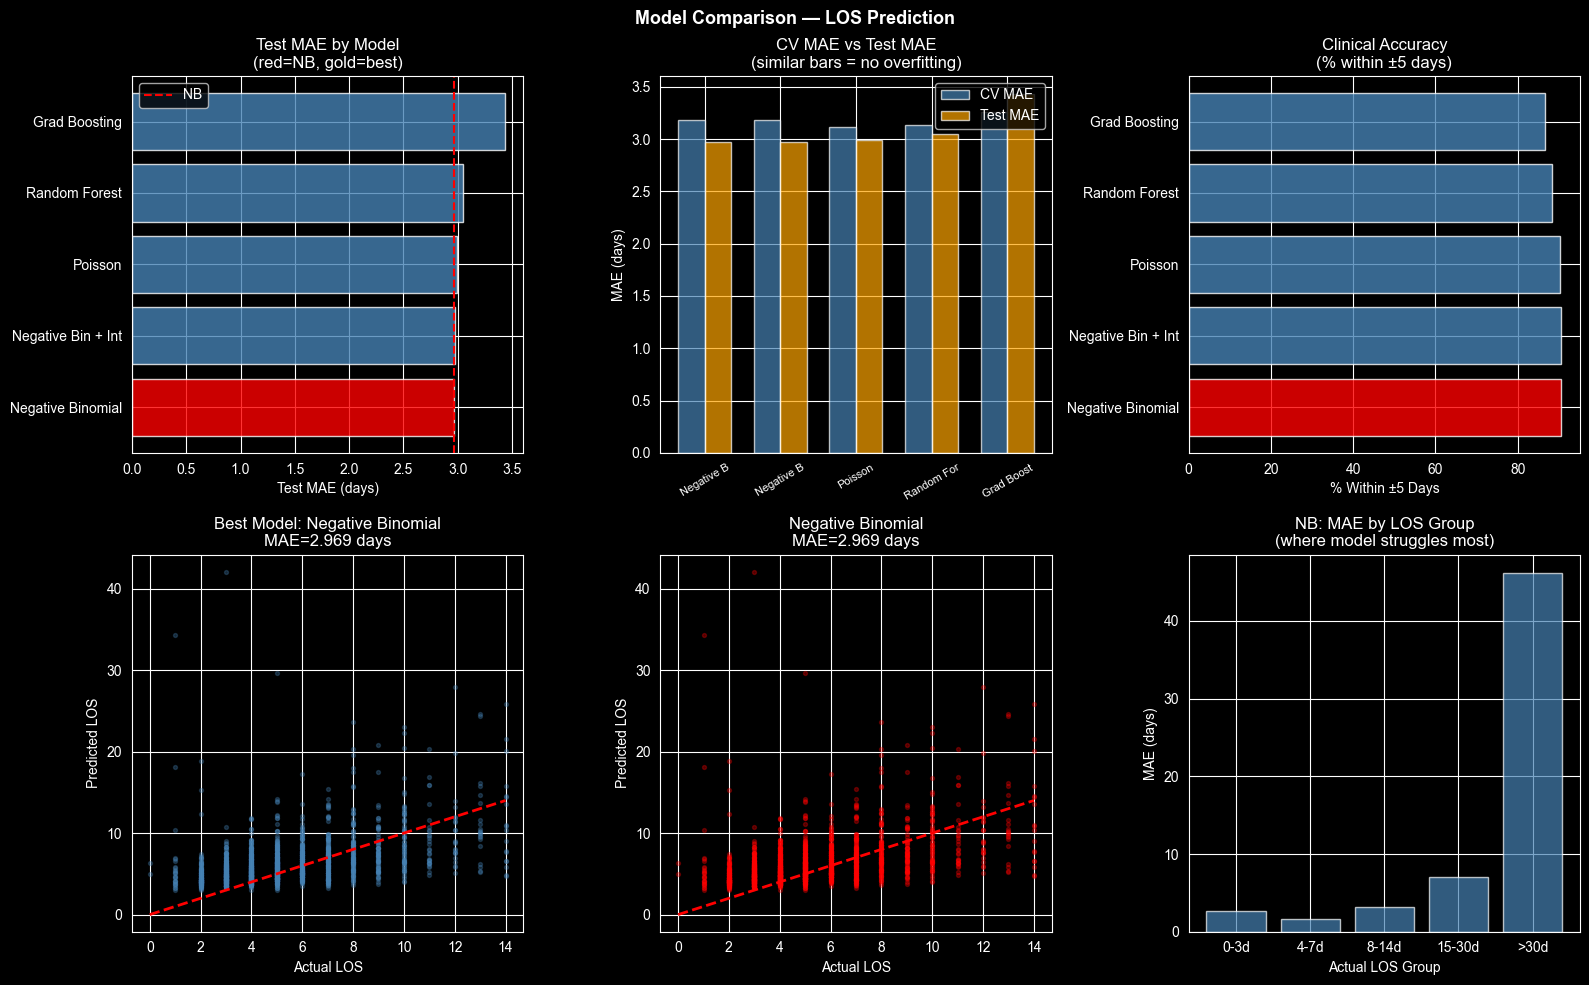

In [113]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

models_ordered = results_df['Model'].tolist()
test_maes      = results_df['MAE'].tolist()
cv_maes_plot   = results_df['CV_MAE'].tolist()
colors         = [
    'red' if m == 'Negative Binomial'
    else 'gold' if mae == min(test_maes)
    else 'steelblue'
    for m, mae in zip(models_ordered, test_maes)
]

# ── Plot 1: Test MAE comparison ───────────────────────────
axes[0,0].barh(
    models_ordered, test_maes,
    color=colors, alpha=0.8
)
axes[0,0].set_xlabel('Test MAE (days)')
axes[0,0].set_title(
    'Test MAE by Model\n'
    '(red=NB, gold=best)'
)
axes[0,0].axvline(
    results_df[results_df['Model']==
               'Negative Binomial']['MAE'].values[0],
    color='red', linestyle='--',
    linewidth=1.5, label='NB'
)
axes[0,0].legend()

# ── Plot 2: CV MAE vs Test MAE ────────────────────────────
x   = np.arange(len(models_ordered))
w   = 0.35
axes[0,1].bar(
    x - w/2, cv_maes_plot,
    w, label='CV MAE', color='steelblue', alpha=0.7
)
axes[0,1].bar(
    x + w/2, test_maes,
    w, label='Test MAE', color='orange', alpha=0.7
)
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(
    [m[:10] for m in models_ordered],
    rotation=30, fontsize=8
)
axes[0,1].set_ylabel('MAE (days)')
axes[0,1].set_title(
    'CV MAE vs Test MAE\n'
    '(similar bars = no overfitting)'
)
axes[0,1].legend()

# ── Plot 3: Within ±5 days ────────────────────────────────
w5_vals = results_df['W±5d'].tolist()
axes[0,2].barh(
    models_ordered, w5_vals,
    color=colors, alpha=0.8
)
axes[0,2].set_xlabel('% Within ±5 Days')
axes[0,2].set_title('Clinical Accuracy\n(% within ±5 days)')

# ── Plot 4: Actual vs Predicted — best model ─────────────
best_model_name = results_df.iloc[0]['Model']
best_pred       = all_preds[best_model_name]
cap             = np.percentile(y_test, 95)
mask            = y_test <= cap

axes[1,0].scatter(
    y_test[mask], best_pred[mask],
    alpha=0.3, s=8, color='steelblue'
)
axes[1,0].plot(
    [0,cap],[0,cap], 'r--', linewidth=2
)
axes[1,0].set_xlabel('Actual LOS')
axes[1,0].set_ylabel('Predicted LOS')
axes[1,0].set_title(
    f'Best Model: {best_model_name}\n'
    f'MAE={results_df.iloc[0]["MAE"]:.3f} days'
)

# ── Plot 5: Actual vs Predicted — NB ─────────────────────
nb_pred = all_preds['Negative Binomial']
axes[1,1].scatter(
    y_test[mask], nb_pred[mask],
    alpha=0.3, s=8, color='red'
)
axes[1,1].plot(
    [0,cap],[0,cap], 'r--', linewidth=2
)
axes[1,1].set_xlabel('Actual LOS')
axes[1,1].set_ylabel('Predicted LOS')
nb_mae = results_df[
    results_df['Model']=='Negative Binomial'
]['MAE'].values[0]
axes[1,1].set_title(
    f'Negative Binomial\n'
    f'MAE={nb_mae:.3f} days'
)

# ── Plot 6: MAE by LOS group — NB ────────────────────────
bins   = [0, 3, 7, 14, 30, np.inf]
labels = ['0-3d','4-7d','8-14d','15-30d','>30d']
grps   = pd.cut(y_test, bins=bins, labels=labels)
resid  = y_test - np.clip(nb_pred, 0, None)

mae_by = pd.DataFrame({
    'group': grps,
    'err':   np.abs(resid)
}).groupby('group', observed=True)['err'].mean()

axes[1,2].bar(
    mae_by.index, mae_by.values,
    color='steelblue', alpha=0.7
)
axes[1,2].set_xlabel('Actual LOS Group')
axes[1,2].set_ylabel('MAE (days)')
axes[1,2].set_title(
    'NB: MAE by LOS Group\n'
    '(where model struggles most)'
)

plt.suptitle(
    'Model Comparison — LOS Prediction',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [115]:
print("\nFINAL MODEL SELECTION")
print("=" * 55)

best_cv   = results_df.sort_values('CV_MAE').iloc[0]
best_test = results_df.sort_values('MAE').iloc[0]
nb_row    = results_df[
    results_df['Model'] == 'Negative Binomial'
].iloc[0]

print(f"  Best CV-MAE:   {best_cv['Model']} "
      f"({best_cv['CV_MAE']:.3f} days)")
print(f"  Best Test MAE: {best_test['Model']} "
      f"({best_test['MAE']:.3f} days)")
print(f"  NB Test MAE:   {nb_row['MAE']:.3f} days")

# Gap between NB and best
gap = nb_row['MAE'] - best_test['MAE']
print(f"\n  Gap (NB vs best): {gap:+.3f} days")

if gap < 0.5:
    print(f"""
  YES NB performs similarly to best model
  → Use NB as primary model
     Reason: clinically interpretable
     IRR has direct clinical meaning
     Standard in epidemiology papers
  → Report best model as sensitivity check
    """)
else:
    print(f"""
    CHECK  {best_test['Model']} outperforms NB
      by {gap:.2f} days MAE
  → Consider {best_test['Model']} for prediction
  → Keep NB for inference/interpretation
  → Report both in paper
    """)

print(f"\nREPORT IN PAPER:")
print(f"  Primary model (NB):")
print(f"    Test MAE  = {nb_row['MAE']:.3f} days")
print(f"    Test RMSE = {nb_row['RMSE']:.3f} days")
print(f"    Within ±5 days = {nb_row['W±5d']:.1f}%")
print(f"    Bias = {nb_row['Bias']:+.3f} days")


FINAL MODEL SELECTION
  Best CV-MAE:   Poisson (3.114 days)
  Best Test MAE: Negative Binomial (2.969 days)
  NB Test MAE:   2.969 days

  Gap (NB vs best): +0.000 days

  YES NB performs similarly to best model
  → Use NB as primary model
     Reason: clinically interpretable
     IRR has direct clinical meaning
     Standard in epidemiology papers
  → Report best model as sensitivity check
    

REPORT IN PAPER:
  Primary model (NB):
    Test MAE  = 2.969 days
    Test RMSE = 10.802 days
    Within ±5 days = 90.5%
    Bias = +0.167 days
